In [127]:
import numpy as np
import pandas as pd
from pathlib import Path
from icecream import ic
import matplotlib.pyplot as plt
from chars import greek, phys
import seaborn as sns


In [2]:
# C_e = 1.6e-19 # electron charge
# e0 = 20.25 # background
# omega_ex = 2 * C_e # exciton frequency Joules
# f_0 = 0.2 # oscillator Hz
# gamma_ex = 50e6 * C_e # 50MeV
# 
# def Re_dielectric(omega):
#     numerator = (f_0 * (omega_ex**2) * ((omega_ex**2)-(omega**2)) )
#     denominator = ( ((omega_ex**2) - (omega**2))**2 + (gamma_ex**2)*(omega**2) )
#     return e0 + ( numerator / denominator )
# 
# def Im_dielectric(omega):
#     numerator = (f_0 * (omega_ex**2) * gamma_ex * omega )
#     denominator = ( ((omega_ex**2) - (omega**2))**2 + (gamma_ex**2)*(omega**2) )
#     return ( numerator / denominator )
# 
# ic(Re_dielectric(C_e))
# ic(Im_dielectric(C_e))

In [115]:
dirac = 1.05457e-34
C_e = 1.6e-19 # electron charge

e0 = 20.25 # background
omega_ex = 2 * C_e / dirac # exciton frequency, converted to radians per second
f_0 = 0.2 # oscillator [arb]
gamma_ex = 50e-3 * C_e / dirac # 50meV, converted to radians per second

a = omega_ex**2

def b(omega):
    return omega**2

def c(omega):
    return gamma_ex * omega


def Re_ep(omega):
    numerator = f_0 * a * (a - b(omega))
    denominator = (a - b(omega))**2 + c(omega)**2
    return e0 + ( numerator / denominator )

def Im_ep(omega):
    numerator = f_0 * a * c(omega)
    denominator = (a - b(omega))**2 + c(omega)**2
    return ( numerator / denominator )


def n_omega(omega):
    f1 = np.sqrt(Re_ep(omega)**2 + Im_ep(omega)**2)
    f2 = np.sqrt(Re_ep(omega) + f1)
    f3 = (1/np.sqrt(2)) * f2
    return f3

def k_omega(omega):
    f1 = np.sqrt(Re_ep(omega)**2 + Im_ep(omega)**2)
    f2 = np.sqrt(-Re_ep(omega) + f1)
    f3 = (1/np.sqrt(2)) * f2
    return f3


def omega_wavelength_um_convert(num):
    return (2 * np.pi * 3e8 / num) * 1e6

min = 0.1
max = 2
n = int((max-min)*1000 + 1)
wavelength_values = np.linspace(min, max, n)

omega_values = np.logspace(15, 16, 100000, base=10.)
omega_values = omega_wavelength_um_convert(wavelength_values)

print(omega_wavelength_um_convert(1e15))


1.8849555921538759


Text(0.5, 1.0, 'n')

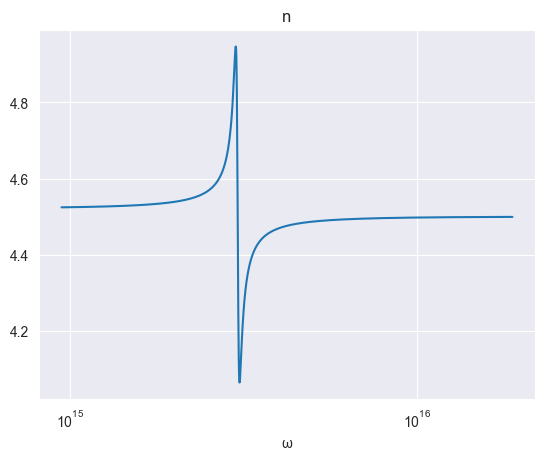

In [116]:


plt.semilogx(omega_values, n_omega(omega_values))
# plt.xlim([1e-30,1e-20])
plt.xlabel(greek.omega)
plt.title('n')

Text(0.5, 0, 'ω')

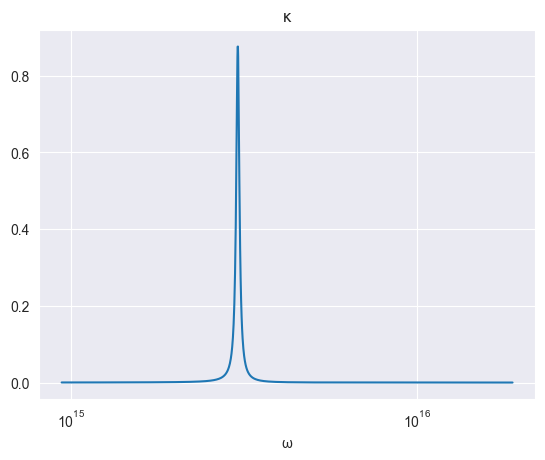

In [117]:
import matplotlib.pyplot as plt
from chars import greek, phys

plt.semilogx(omega_values, k_omega(omega_values))
# plt.xlim([1e-30,1e-20])
plt.title(greek.kappa)
plt.xlabel(greek.omega)


In [134]:

c_light = 3e8
min_wavelength_um = 0.2
max_wavelength_um = 2

df = pd.DataFrame({'omega':omega_values, 'n':n_omega(omega_values), 'k':k_omega(omega_values)})
df['wavelength'] = (2 * np.pi * c_light / df['omega']) * 1e6

df_wave = df[['wavelength', 'n', 'k']].query(f"wavelength >= {min_wavelength_um} and wavelength <= {max_wavelength_um}").reset_index(drop=True)
df_wave.info()
df_wave.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1801 entries, 0 to 1800
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   wavelength  1801 non-null   float64
 1   n           1801 non-null   float64
 2   k           1801 non-null   float64
dtypes: float64(3)
memory usage: 42.3 KB


,wavelength,n,k
0,0.200,4.497430,0.000023
1,0.201,4.497401,0.000023
2,0.202,4.497372,0.000024
3,0.203,4.497343,0.000024
4,0.204,4.497313,0.000025


Text(0, 0.5, 'n,k')

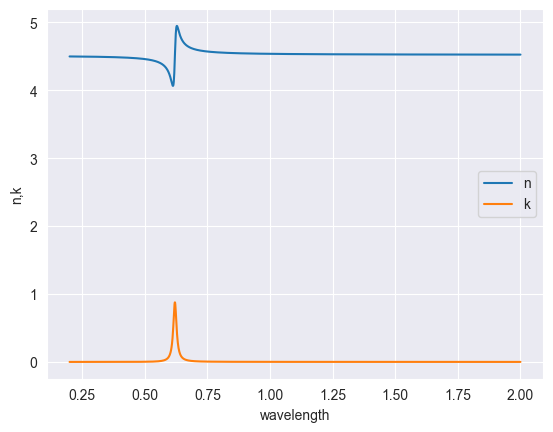

In [129]:

sns.lineplot(df_wave, x='wavelength', y='n', label='n')
sns.lineplot(df_wave, x='wavelength', y='k', label='k')
plt.ylabel('n,k')
# plt.xlim([0.5, 0.7])

In [131]:
import os

cwd = Path.cwd()
materials_dir = cwd / 'WS2_Grating_Eamonn' / 'Materials' / 'Zong et al. Lorentzian WS2'
materials_dir.mkdir(exist_ok=True)

os.listdir(materials_dir)


[]

In [135]:
df_wave.to_csv(materials_dir / '2eV_ex_lorentzian_Zong.csv', sep='\t', index=False, header=False, float_format='%.6f')

In [61]:
print()